In [40]:
import os

import pandas as pd


def read_txt_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()
    lines = content.split('\n')
    metrics = []
    values = []
    for line in lines[2:]:
        if line.strip():  # Skip empty lines
            metric, value = line.split(':')
            metrics.append(metric.strip())
            values.append(float(value.strip()))
    df = pd.DataFrame({'Metric': metrics, 'Value': values})
    return df

In [41]:
os.path.exists("../../../results/cof_rth_0.99_0.9")

True

In [42]:
results_dir = "../../../results/cof_rth_0.99_0.9"

df_summary = []
for model in os.listdir(results_dir):
    model_dir = os.path.join(results_dir, model)
    for dataset in os.listdir(model_dir):
        dataset_dir = os.path.join(model_dir, dataset)
        result_file = os.path.join(dataset_dir, 'aggregated_results.txt')
        try:
            df_metrics = read_txt_file(result_file)
            df_metrics['Model'] = model
            dataset_name = dataset.replace('rth_1.0', '').replace('True', '').replace('1024', '').replace('sum', '').replace('_', ' ').replace('2', '')
            dataset_name = dataset_name.replace('features', '')
            df_metrics['Dataset'] = dataset_name

            df_summary.append(df_metrics)
        except FileNotFoundError:
            print(f"File not found: {result_file}")
            continue
df_summary = pd.concat(df_summary, ignore_index=True)
df_summary.head()

,Metric,Value,Model,Dataset
0,pairwise_accuracy_score,0.4386,xgboost,descriptor
1,baseline_pairwise_accuracy_score,0.5000,xgboost,descriptor
2,ndcg_score,0.7879,xgboost,descriptor
3,baseline_ndcg_score,0.8273,xgboost,descriptor
4,rmse,210.8842,xgboost,descriptor


In [43]:
def visualize_metric(df, metric_name):
    import seaborn as sns
    import matplotlib.pyplot as plt

    df_metric = df[df['Metric'] == metric_name]
    df_metric_baseline = df[df['Metric'] == f'baseline_{metric_name}']

    df_metric = pd.pivot(df_metric, index='Dataset', columns='Model', values='Value')
    df_metric_baseline = pd.pivot(df_metric_baseline, index='Dataset', columns='Model', values='Value')
    df_metric_baseline = df_metric_baseline.iloc[[0], :]


    #display(df_metric_baseline)
    #display(df_metric)

    fig = plt.figure(figsize=(24, 12))

    if metric_name in ['rmse', 'mae', 'smape', 'mape']:
        cmap = 'magma_r'
        df_metric_small = df_metric[df_metric < df_metric_baseline.values[0][0] * 1.5]
        vmax = df_metric_small.max().max()
        vmin = df_metric_small.min().min()
    else:
        cmap = 'magma'
        df_metric_small = df_metric[df_metric <= 1]
        vmax = df_metric_small.max().max()
        vmin = df_metric_small.min().min()

    # 2. Create a GridSpec with height ratios
    gs = fig.add_gridspec(2, 1, height_ratios=[1, len(df_metric.index)])

    # 3. Add subplots using the GridSpec object
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])

    sns.heatmap(data=df_metric_baseline, annot=True, ax=ax0, cmap=cmap, vmax=vmax, vmin=vmin, fmt=".2f")
    ax0.set_title(f'Baseline {metric_name} Scores')
    sns.heatmap(data=df_metric, annot=True, ax=ax1, cmap=cmap, vmax=vmax, vmin=vmin, fmt=".2f")
    ax1.set_title(f'{metric_name} Scores by Model')
    plt.tight_layout()
    plt.show()

pairwise_accuracy_score


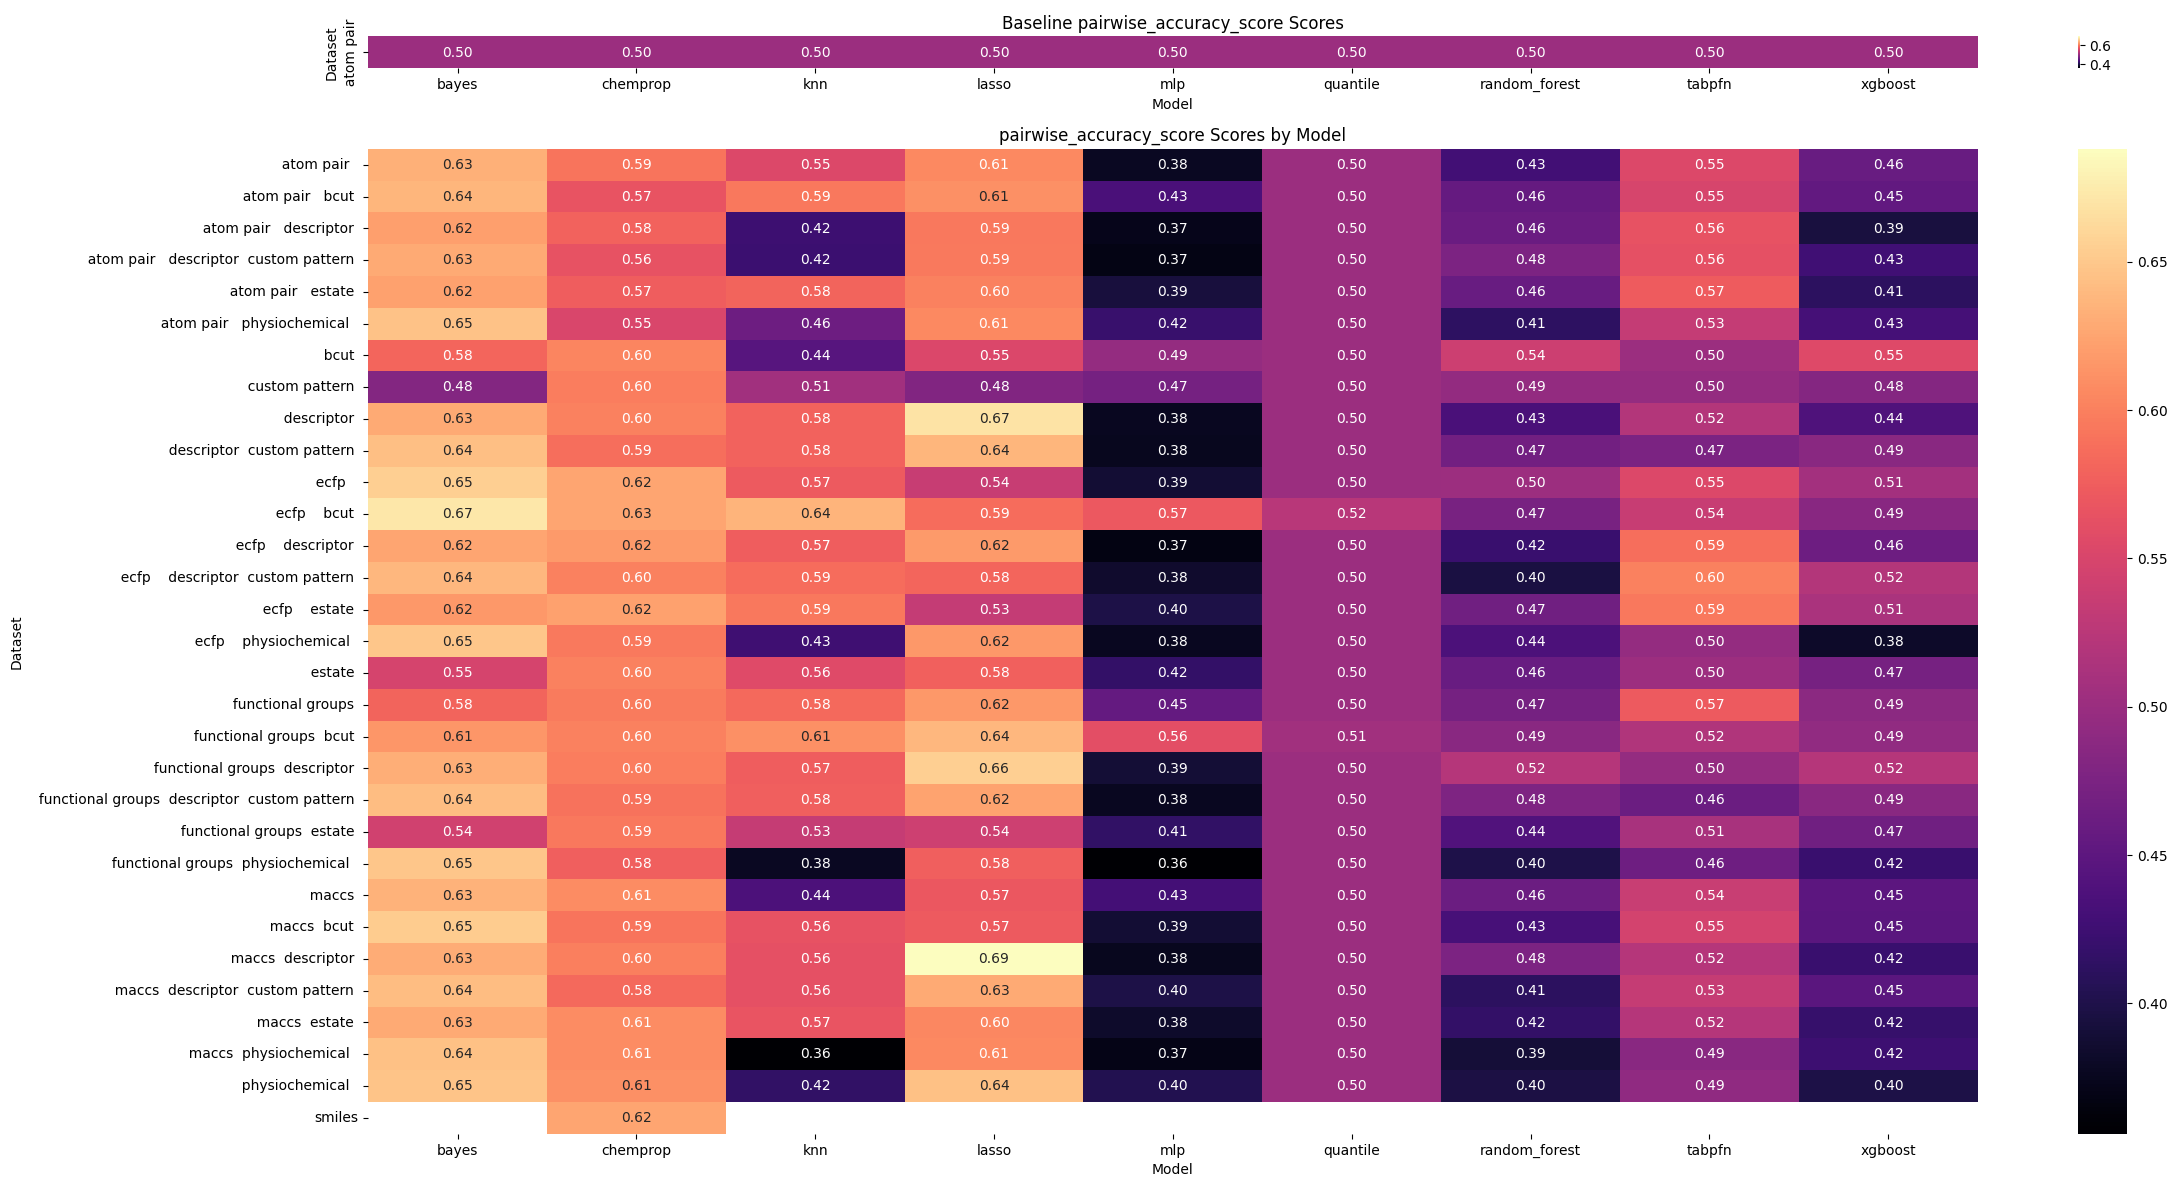

ndcg_score


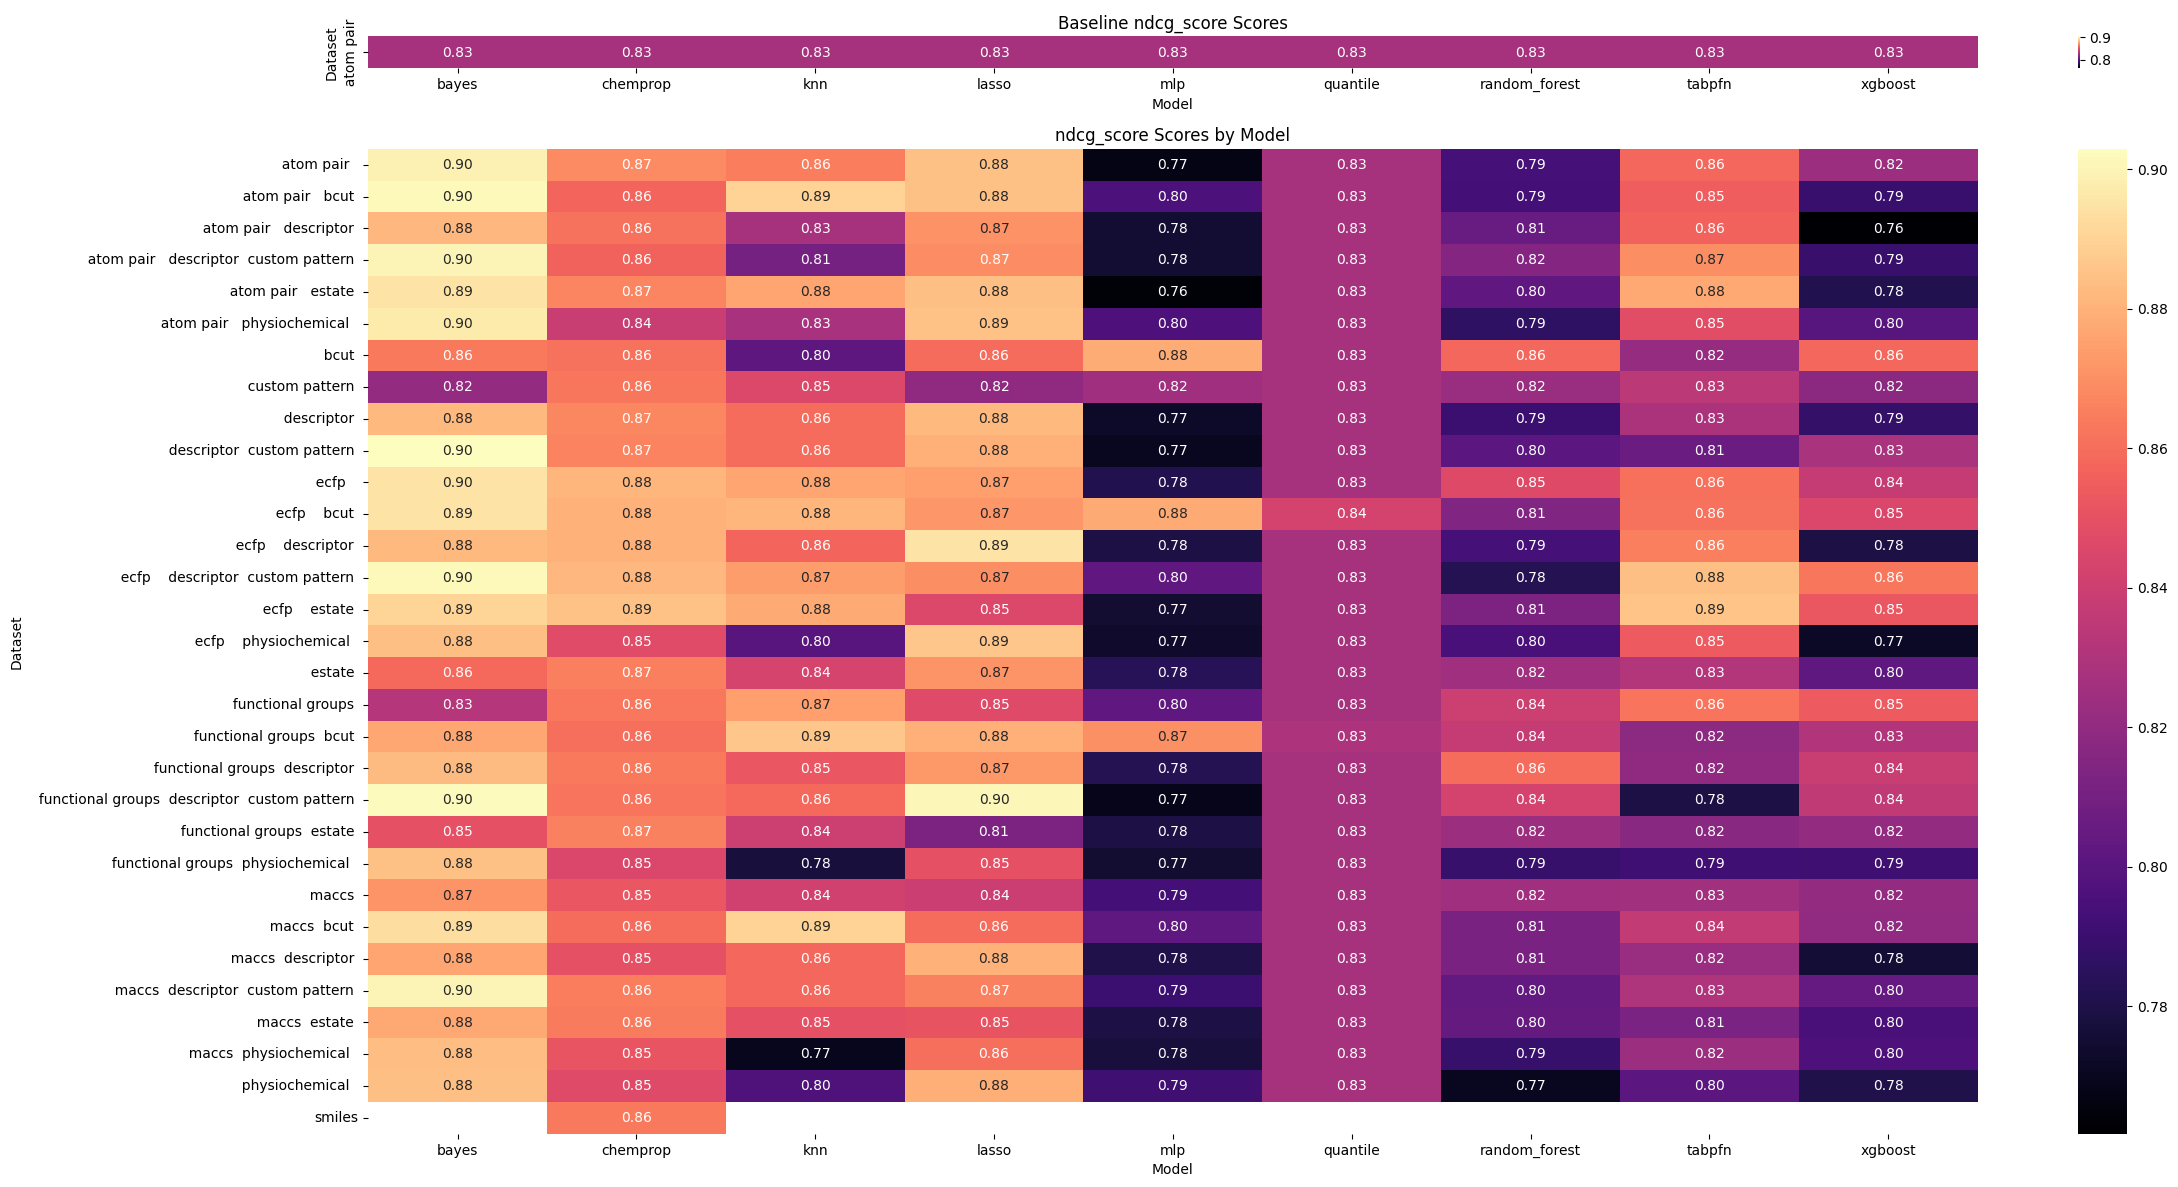

rmse


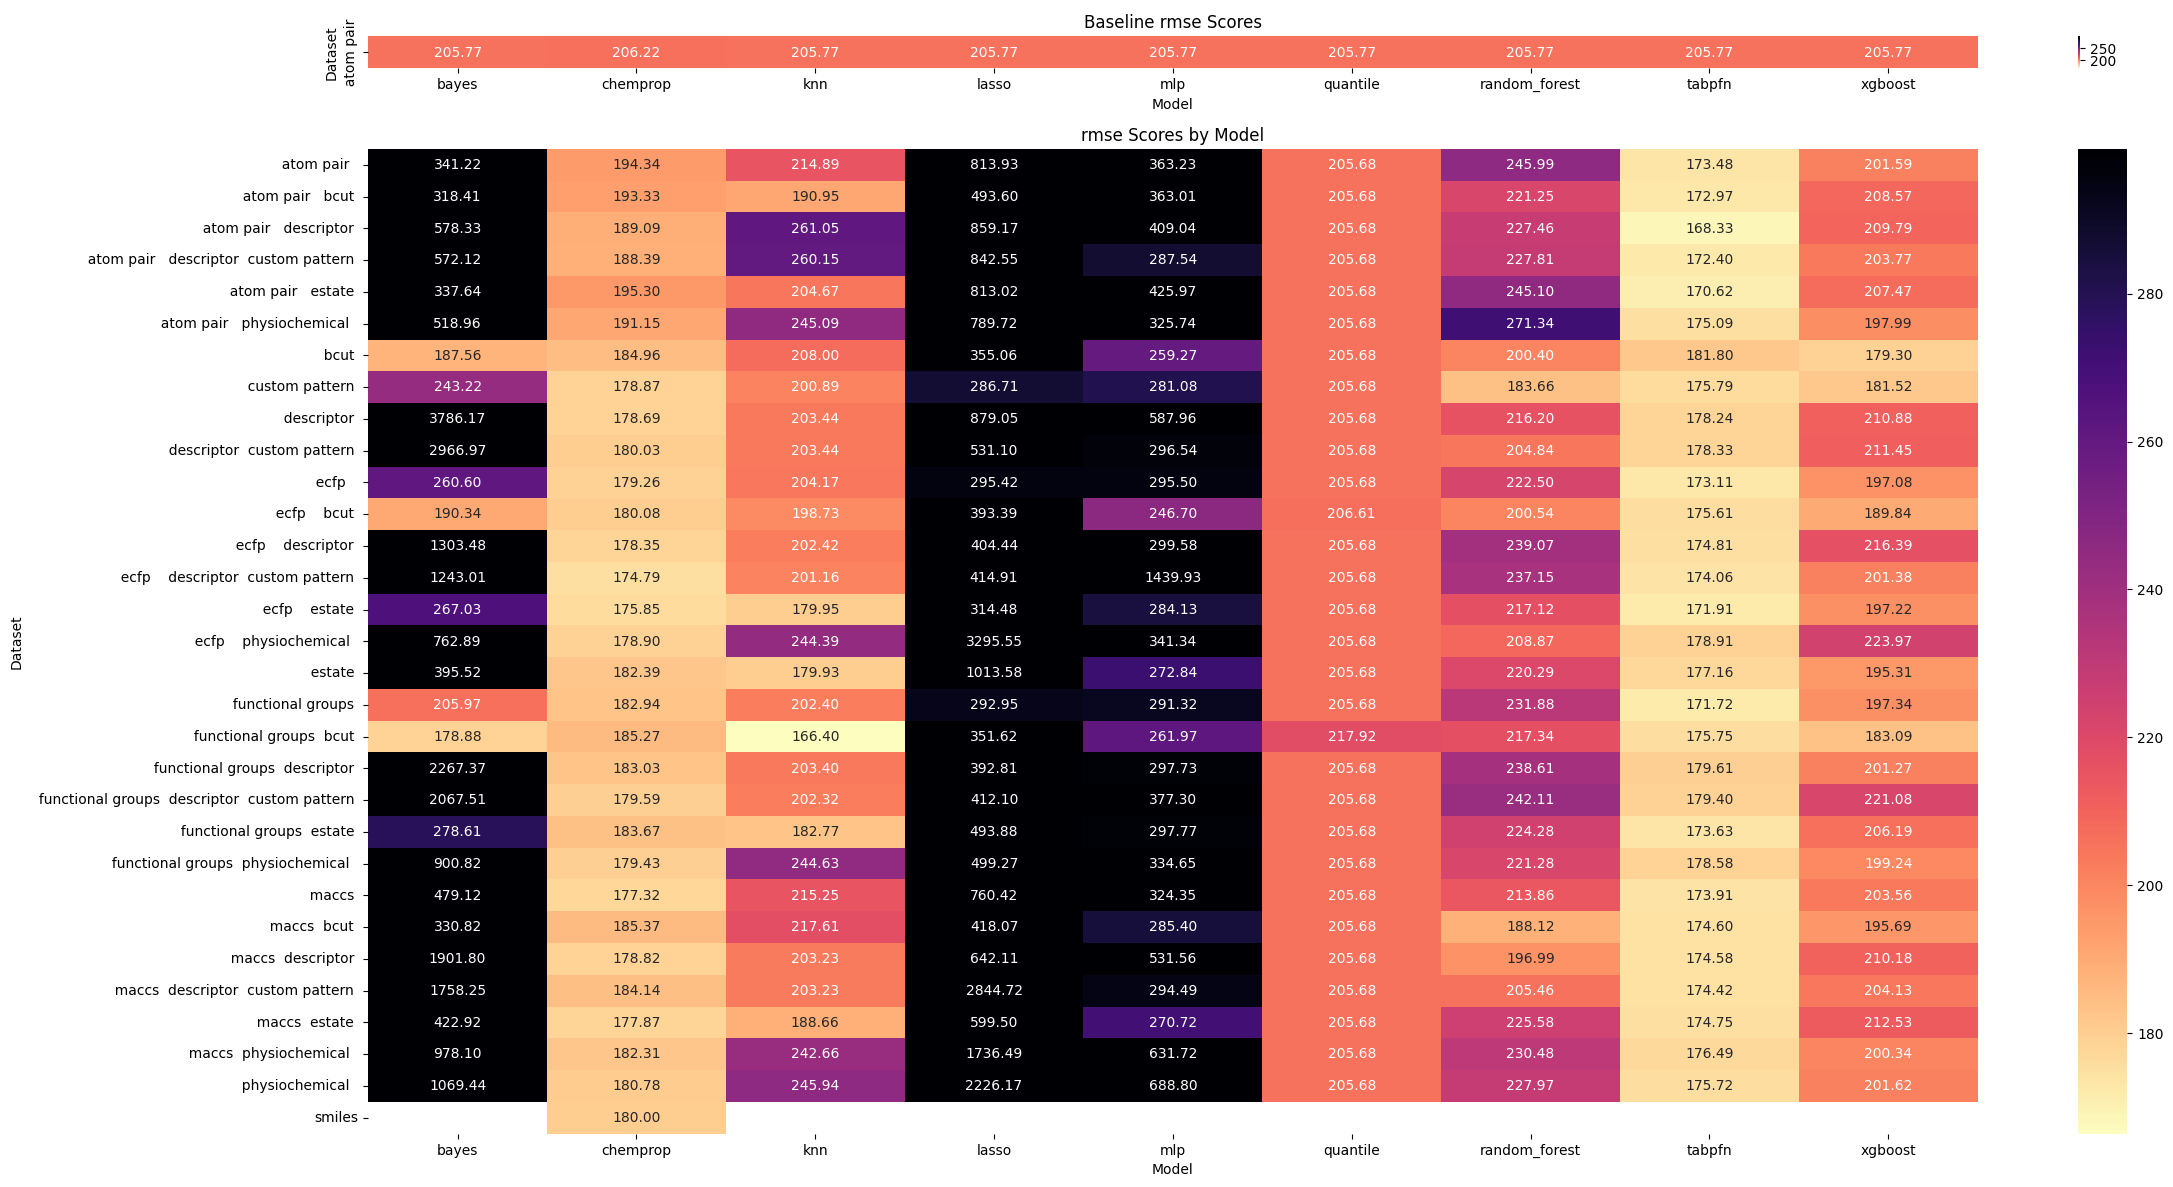

mae


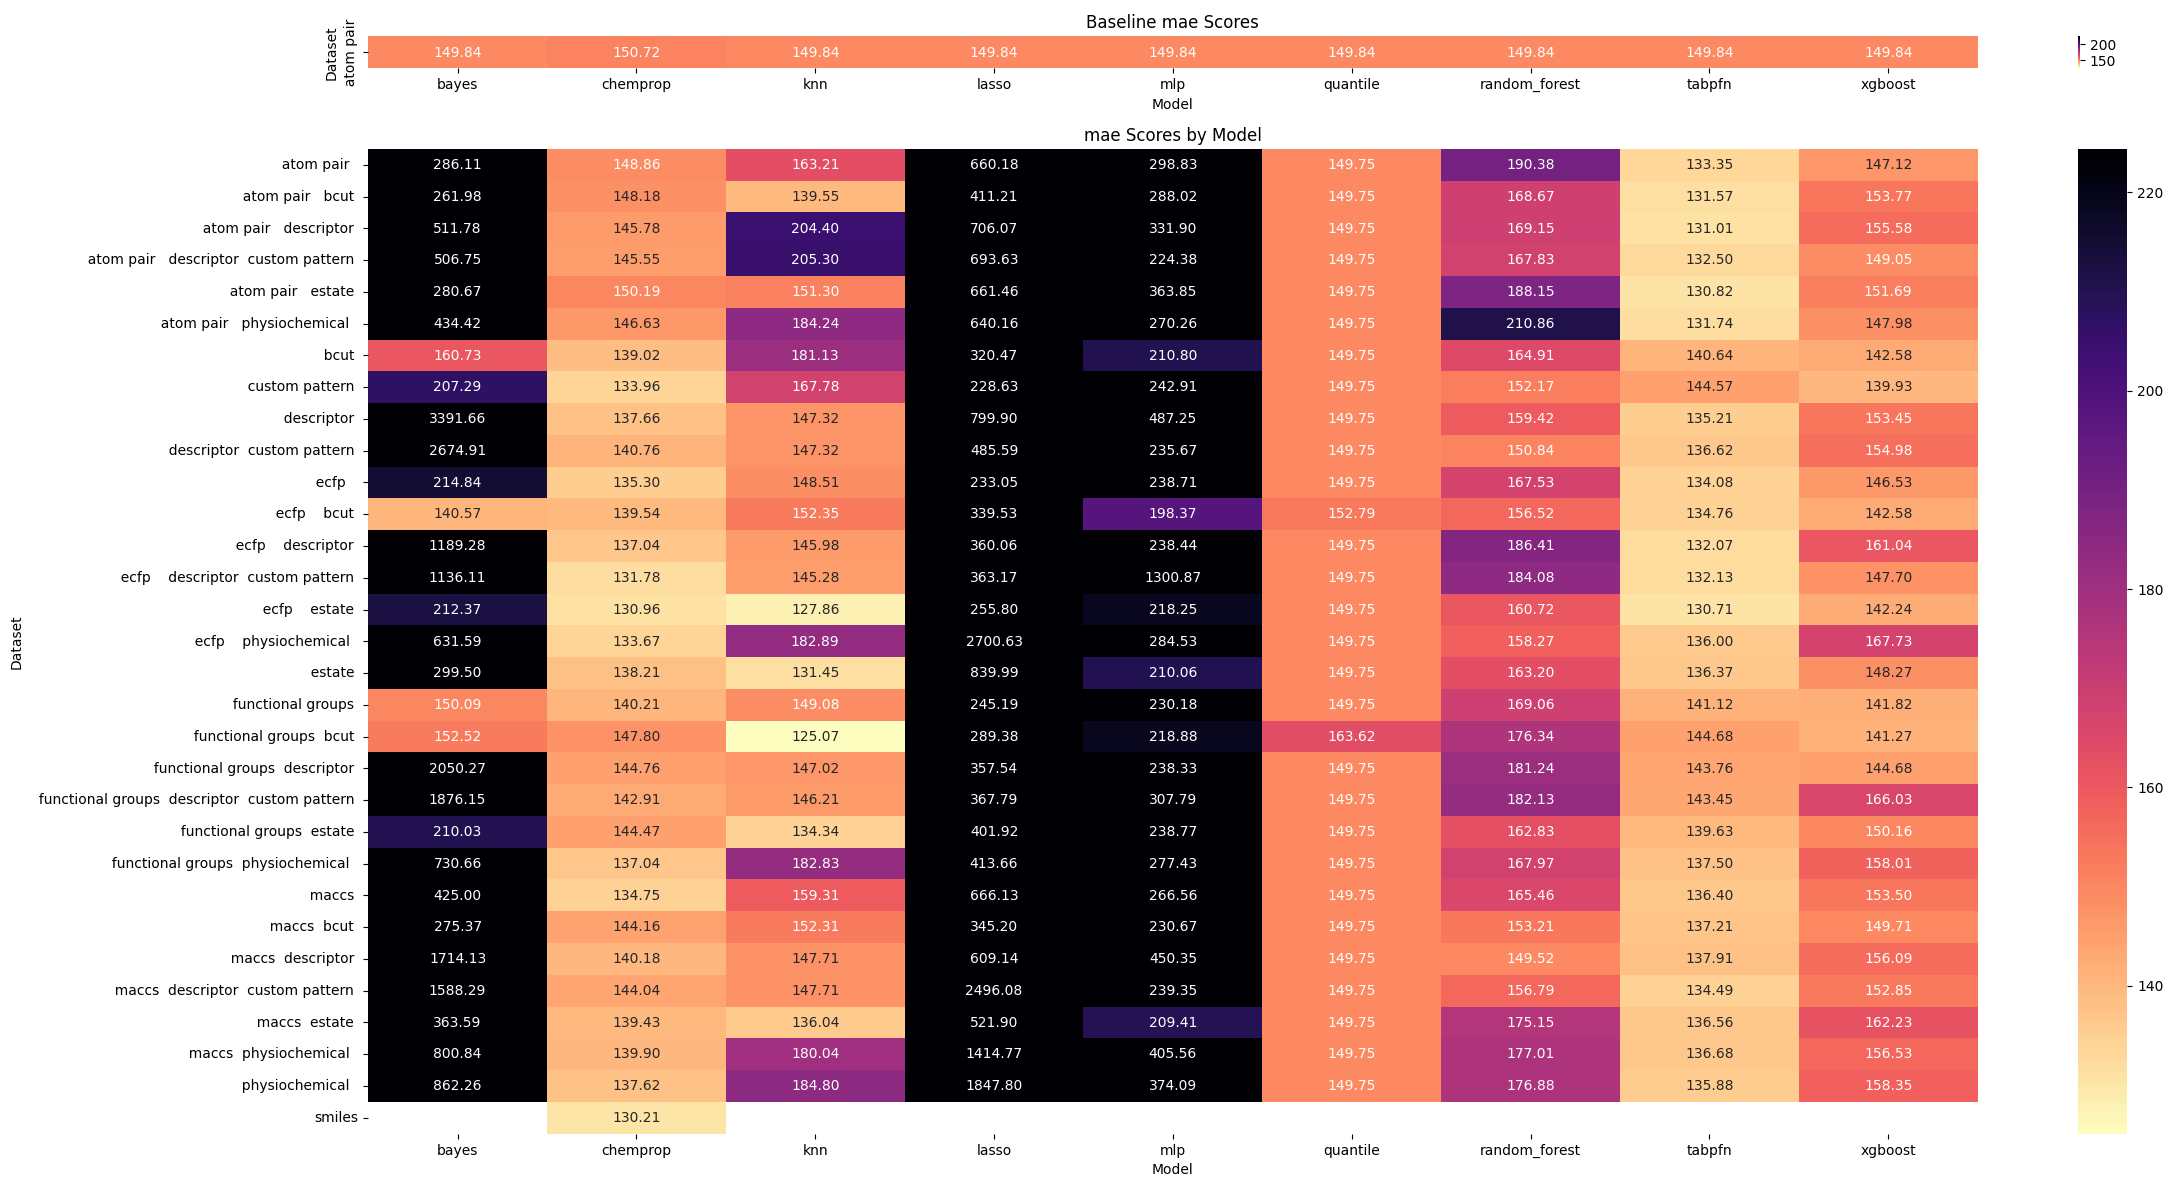

mape


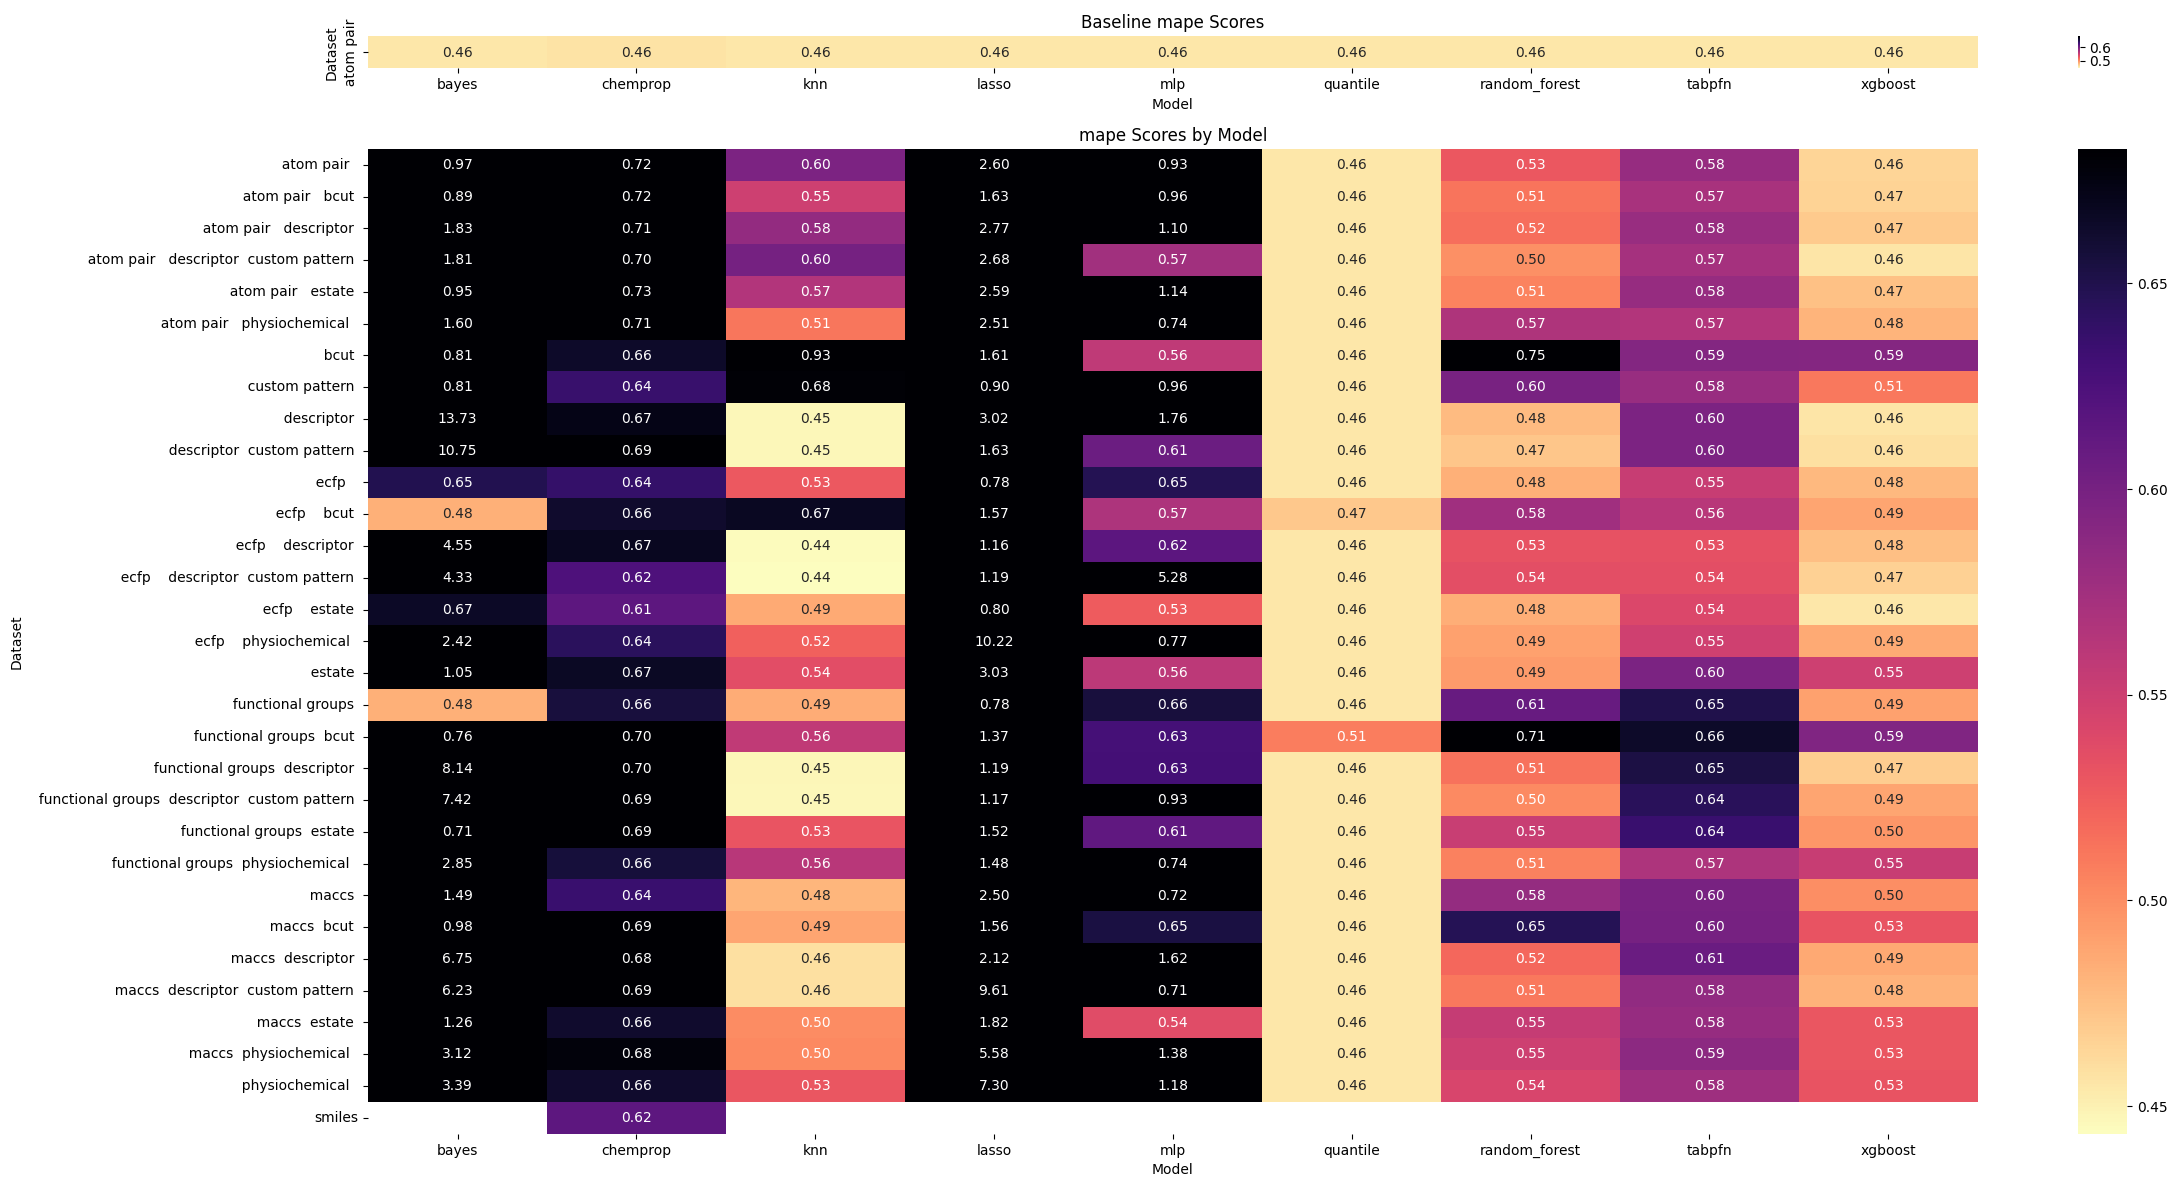

smape


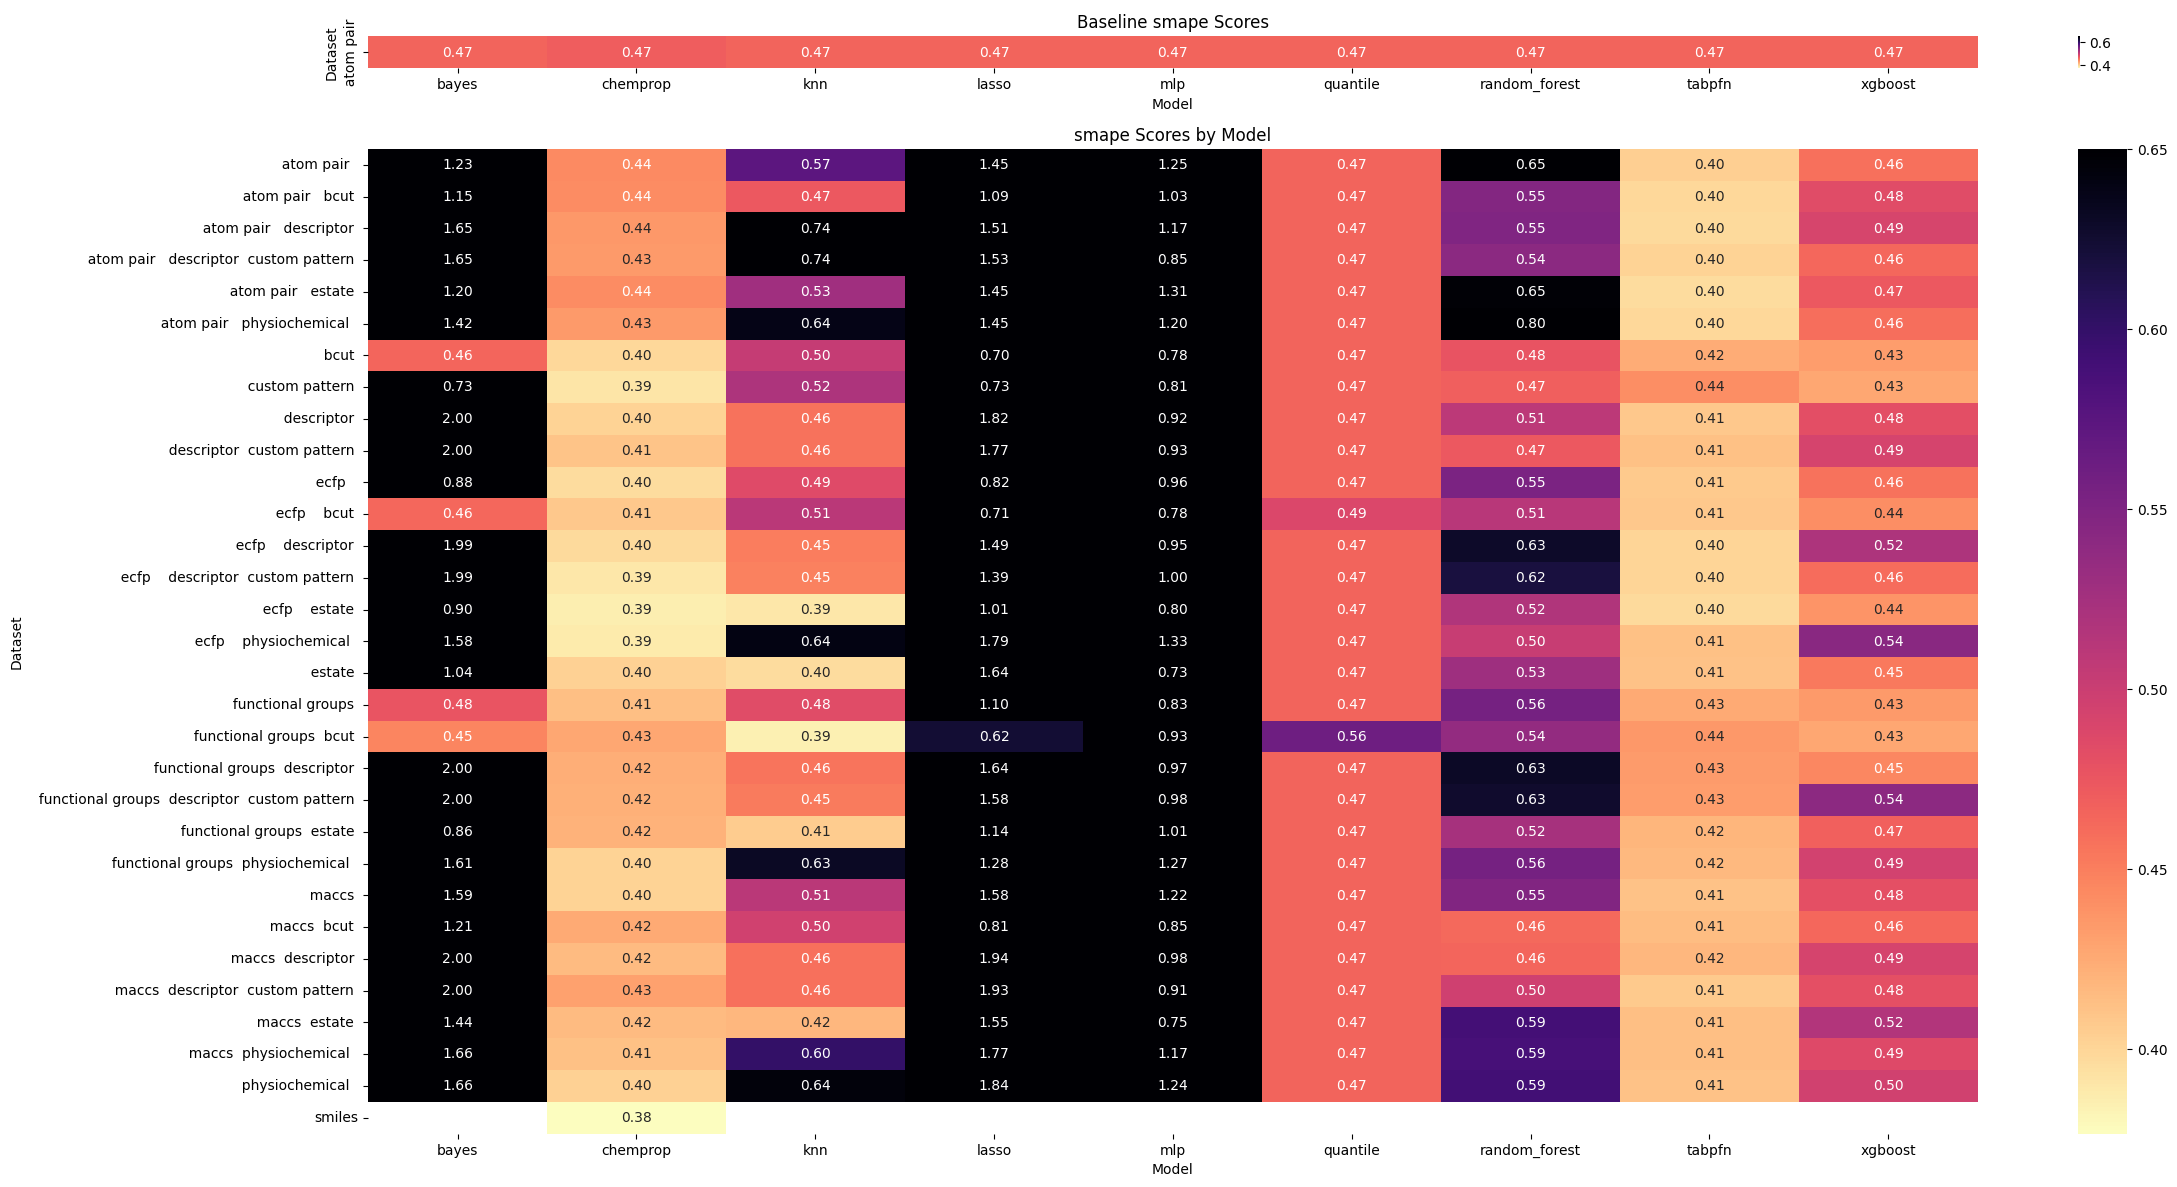

r2_score


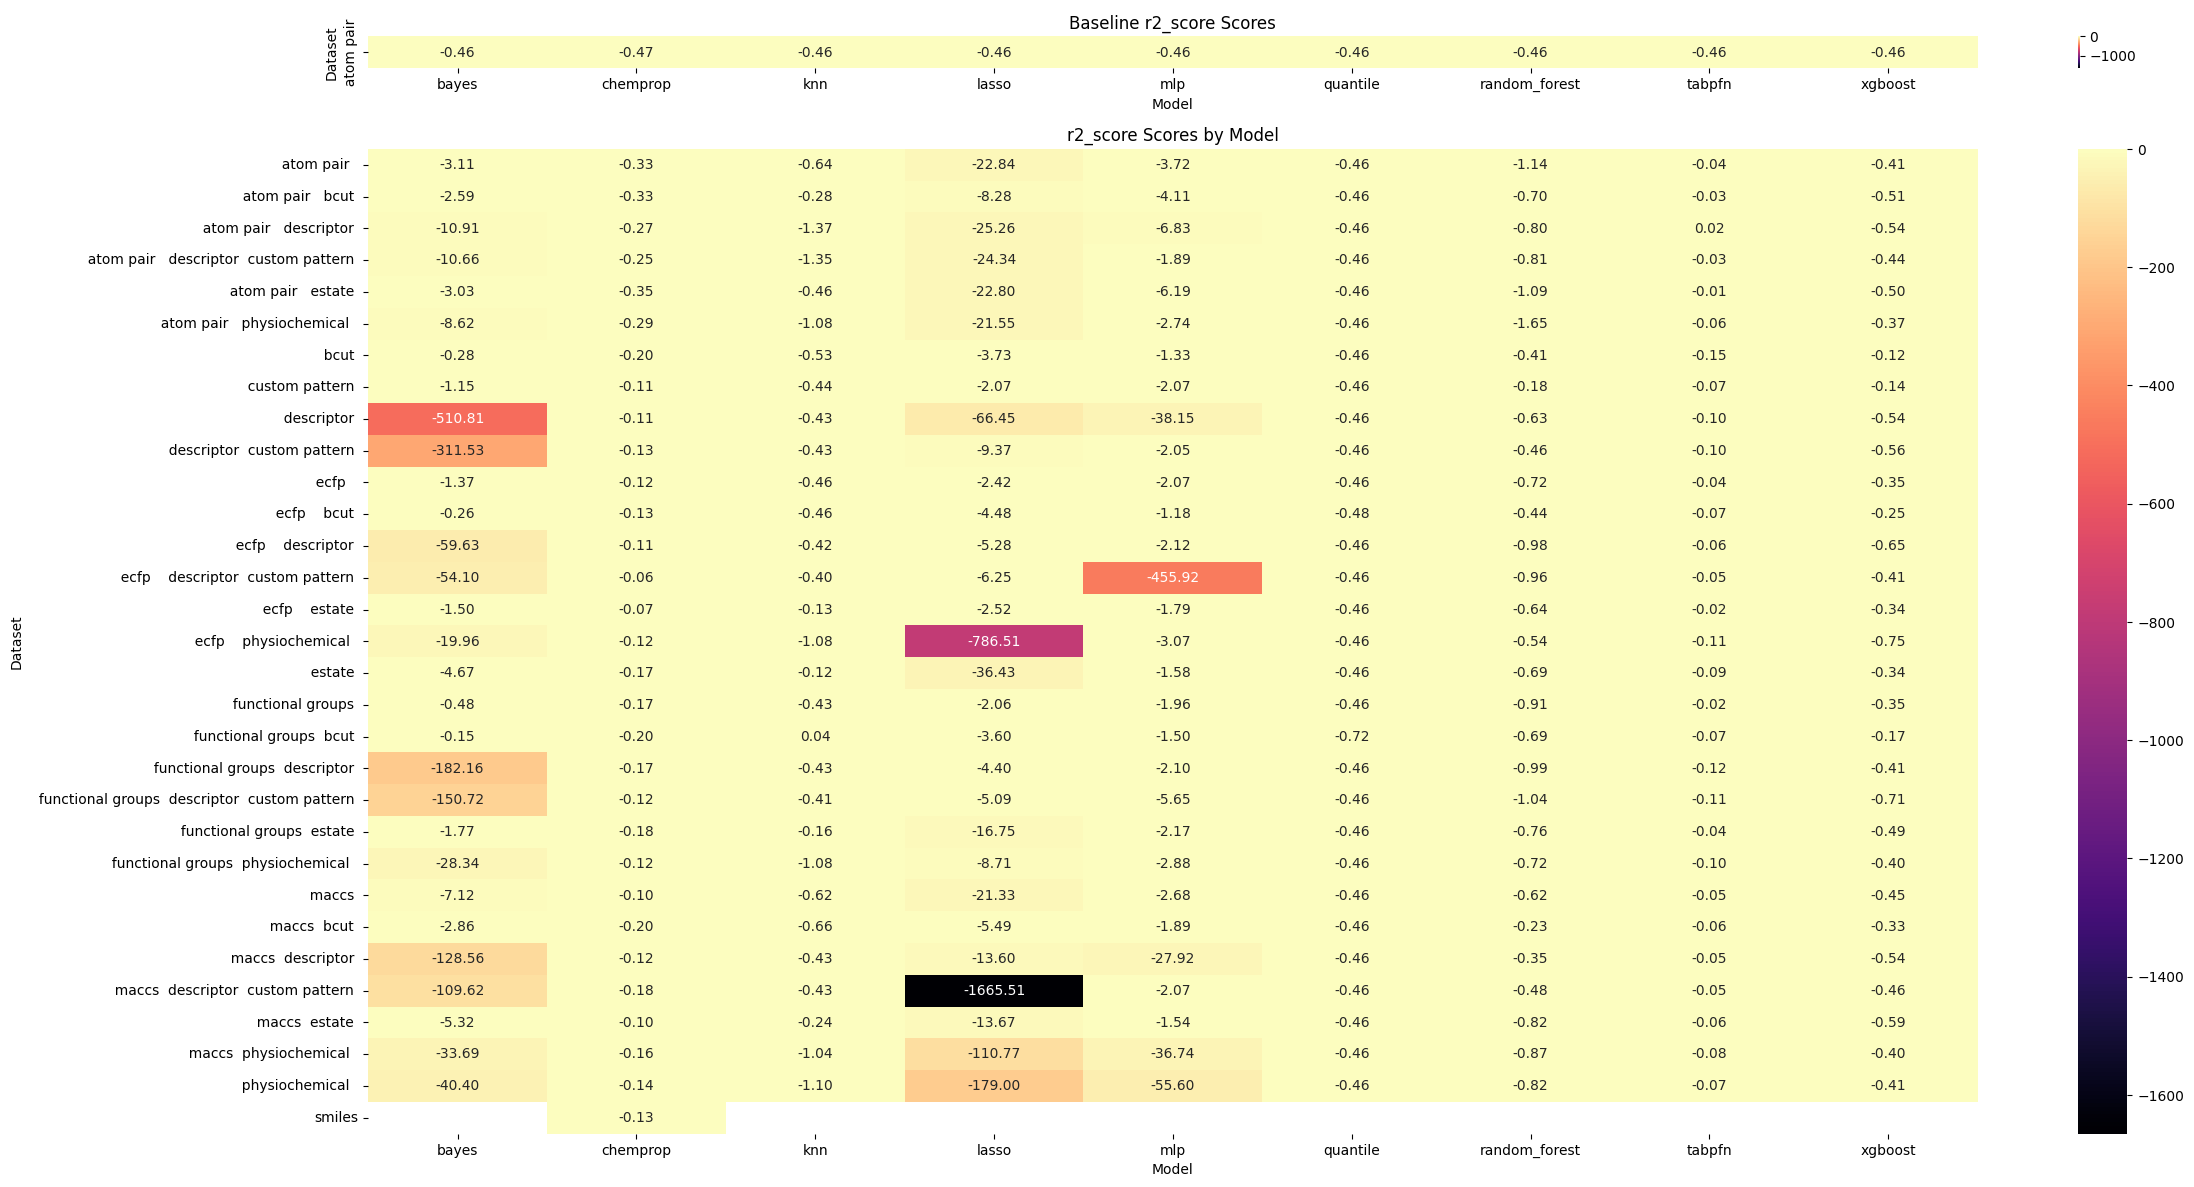

In [44]:
for metric in df_summary['Metric'].unique():
    if 'baseline' not in metric:
        print(metric)
        visualize_metric(df_summary, metric)